# Robust Non-negative Matrix Factorization for Face Image Clustering

Comparison of four NMF variants under salt-and-pepper noise on the ORL and Extended Yale B datasets.

This notebook contains the complete preprocessing, factorization, clustering, and evaluation workflow for a four-person COMP5328 Advanced Machine Learning project (Semester 2, 2025).

The experiments cover:
- ORL and Extended Yale B face-image preprocessing;
- salt-and-pepper noise simulation;
- L2-NMF, L1-NMF, L2,1-NMF, and hypersurface/Charbonnier NMF;
- clustering Accuracy, normalized mutual information (NMI), and relative reconstruction error (RRE).

**Dataset note:** Dataset files are not included. Obtain them from an authorized source and place them under `data/` as documented in the repository README.

## 1. Load Dataset

### 1.0 Data Folder

In [1]:
# The structure of data folder.
!ls -l data

total 0
drwxrwxrwx@ 41 htg  staff  1312 Aug 25  2018 CroppedYaleB
drwx------@ 44 htg  staff  1408 Aug 24  2018 ORL


### 1.1 Load ORL Dataset and Extended YaleB Dataset.
+ ORL dataset contains ten different images of each of 40 distinct subjects. For some subjects, the images were taken at different times, varying the lighting, facial expressions (open / closed eyes, smiling / not smiling) and facial details (glasses / no glasses). All the images were taken against a dark homogeneous background with the subjects in an upright, frontal position (with tolerance for some side movement). The size of each image is 92x112 pixels, with 256 grey levels per pixel. To further reduce the computation complexity, you can resize all images to 30x37 pixels.

+ Extended YaleB dataset contains 2414 images of 38 human subjects under 9 poses and 64 illumination conditions. All images are manually aligned, cropped, and then resized to 168x192 pixels. To further reduce the computation complexity, you can resize all images to 42x48 pixels.

In [2]:
# Fix warnings for Windows environment
import os
import warnings

# Set environment variables to fix warnings
os.environ['LOKY_MAX_CPU_COUNT'] = '4' 
os.environ['OMP_NUM_THREADS'] = '2'   

# Suppress specific warnings
warnings.filterwarnings('ignore', category=UserWarning, module='joblib')
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.cluster._kmeans')


In [3]:
import os
import numpy as np
from PIL import Image

def load_data(root, reduce):
    """ 
    Load ORL (or Extended YaleB) dataset to numpy array.
    
    Args:
        root: path to dataset.
        reduce: scale factor for zooming out images.
        
    """ 
    images, labels = [], []

    for i, person in enumerate(sorted(os.listdir(root))):
        
        if not os.path.isdir(os.path.join(root, person)):
            continue
        
        for fname in os.listdir(os.path.join(root, person)):    
            
            # Remove background images in Extended YaleB dataset.
            if fname.endswith('Ambient.pgm'):
                continue
            
            if not fname.endswith('.pgm'):
                continue
                
            # load image.
            img = Image.open(os.path.join(root, person, fname))
            img = img.convert('L') # grey image.

            # reduce computation complexity.
            img = img.resize([s//reduce for s in img.size])

            # convert image to numpy array.
            img = np.asarray(img).reshape((-1,1))

            # collect data and label.
            images.append(img)
            labels.append(i)

    # concate all images and labels.
    images = np.concatenate(images, axis=1)
    labels = np.array(labels)

    return images, labels

In [4]:
# Load ORL dataset.
X_ORL, Y_ORL = load_data(root='data/ORL', reduce=2)
print('ORL dataset: X.shape = {}, Y.shape = {}'.format(X_ORL.shape, Y_ORL.shape))

# Load Extended YaleB dataset.
X_YaleB, Y_YaleB = load_data(root='data/CroppedYaleB', reduce=3)
print('Extended YaleB dataset: X.shape = {}, Y.shape = {}'.format(X_YaleB.shape, Y_YaleB.shape))

ORL dataset: X.shape = (2576, 400), Y.shape = (400,)
Extended YaleB dataset: X.shape = (3584, 2414), Y.shape = (2414,)


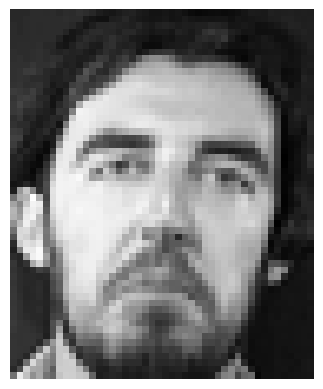

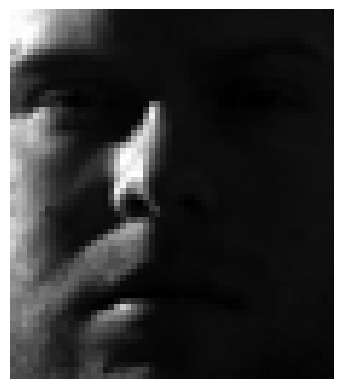

In [5]:
import matplotlib.pyplot as plt

# ORL
H0_ORL, W0_ORL = 112, 92
H, W = H0_ORL // 2, W0_ORL // 2   # reduce=2
plt.imshow(X_ORL[:, 20].reshape(H, W), cmap='gray'); plt.axis('off'); plt.show()

# Extended YaleB
H0_YaleB, W0_YaleB = 192, 168
H, W = H0_YaleB // 3, W0_YaleB // 3   # reduce=3
plt.imshow(X_YaleB[:, 0].reshape(H, W), cmap='gray'); plt.axis('off'); plt.show()

---------------------------


## 2. Evaluation Metrics


### 2.1 Relative Reconstruction Errors (RRE)

To compare the robustness of different NMF algorithms, you can use the ```relative reconstruction errors```. Let $V$ denote the contaminated dataset (by adding noise), and $\hat{V}$
 denote the clean dataset. Let $W$ and $H$ denote the factorization results on $V$, the ``relative reconstruction errors`` then can be defined as follows:
 \begin{equation}
    RRE = \frac{ \| \hat{V} - WH \|_F }{ \| \hat{V} \|_F}.
\end{equation}


In [6]:
# Add salt and pepper noise.
import numpy as np

def add_salt_and_pepper_noise(image, p, s):
    noisy_image = np.copy(image)
    total_pixels = image.size

    num_noise = int(p * total_pixels)
    num_salt = int(s * num_noise)
    num_pepper = num_noise - num_salt

    salt_coords = np.random.choice(total_pixels, num_salt, replace=False)
    noisy_image.flat[salt_coords] = 1

    remaining_pixels = list(set(range(total_pixels)) - set(salt_coords))
    pepper_coords = np.random.choice(remaining_pixels, num_pepper, replace=False)
    noisy_image.flat[pepper_coords] = 0

    return noisy_image

def add_noise_to_dataset(V, r, p, H, W):
    V_noise = np.zeros_like(V)
    for i in range(V.shape[1]):
        img = V[:, i].reshape(H, W)
        noisy_img = add_salt_and_pepper_noise(img, r, p)
        V_noise[:, i] = noisy_img.flatten()
    return V_noise



==> Load ORL dataset ...
V_hat.shape=(2576, 400), Y_hat.shape=(400,)
==> Load CroppedYaleB dataset ...
V_hat.shape=(3584, 2414), Y_hat.shape=(2414,)
ORL image example:


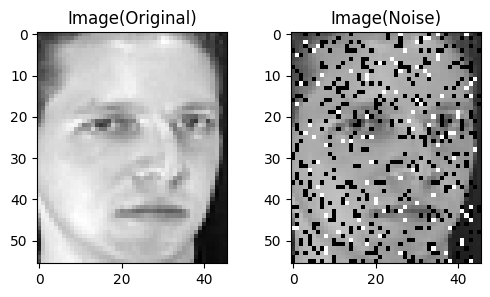

YaleB image example:


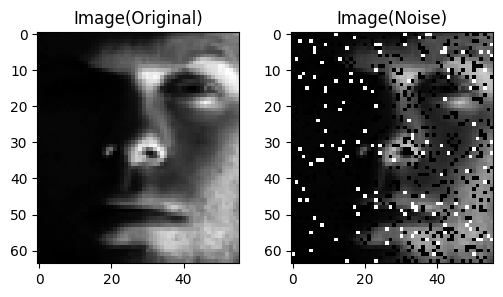

In [7]:
# Load dataset.
print('==> Load ORL dataset ...')
reduce_ORL = 2
V_hat_ORL, Y_hat_ORL = load_data('data/ORL', reduce_ORL)
V_hat_ORL = V_hat_ORL / 255.0  
print('V_hat.shape={}, Y_hat.shape={}'.format(V_hat_ORL.shape, Y_hat_ORL.shape))
V_ORL = add_noise_to_dataset(V_hat_ORL, r=0.2, p=0.2, H=H0_ORL // reduce_ORL, W=W0_ORL // reduce_ORL)

print('==> Load CroppedYaleB dataset ...')
reduce_YaleB = 3
V_hat_YaleB, Y_hat_YaleB = load_data('data/CroppedYaleB', reduce_YaleB)
V_hat_YaleB = V_hat_YaleB / 255.0
print('V_hat.shape={}, Y_hat.shape={}'.format(V_hat_YaleB.shape, Y_hat_YaleB.shape))
V_YaleB = add_noise_to_dataset(V_hat_YaleB, r=0.2, p=0.2, H=H0_YaleB // reduce_YaleB, W=W0_YaleB // reduce_YaleB)


# Plot result.
import matplotlib.pyplot as plt
# ORL
print('ORL image example:')
img_size = [W0_ORL // reduce_ORL, H0_ORL // reduce_ORL]
ind = 5 
plt.figure(figsize=(6, 3))  
plt.subplot(1, 2, 1)
plt.imshow(V_hat_ORL[:,ind].reshape(img_size[1],img_size[0]), cmap=plt.cm.gray)
plt.title('Image(Original)')
plt.subplot(1, 2, 2)
plt.imshow(V_ORL[:,ind].reshape(img_size[1],img_size[0]), cmap=plt.cm.gray)
plt.title('Image(Noise)')
plt.show()

# YaleB
print('YaleB image example:')
img_size = [W0_YaleB // reduce_YaleB, H0_YaleB // reduce_YaleB]
ind = 5 
plt.figure(figsize=(6,3))
plt.subplot(1, 2, 1)
plt.imshow(V_hat_YaleB[:,ind].reshape(img_size[1],img_size[0]), cmap=plt.cm.gray)
plt.title('Image(Original)')
plt.subplot(1, 2, 2)
plt.imshow(V_YaleB[:,ind].reshape(img_size[1],img_size[0]), cmap=plt.cm.gray)
plt.title('Image(Noise)')
plt.show()



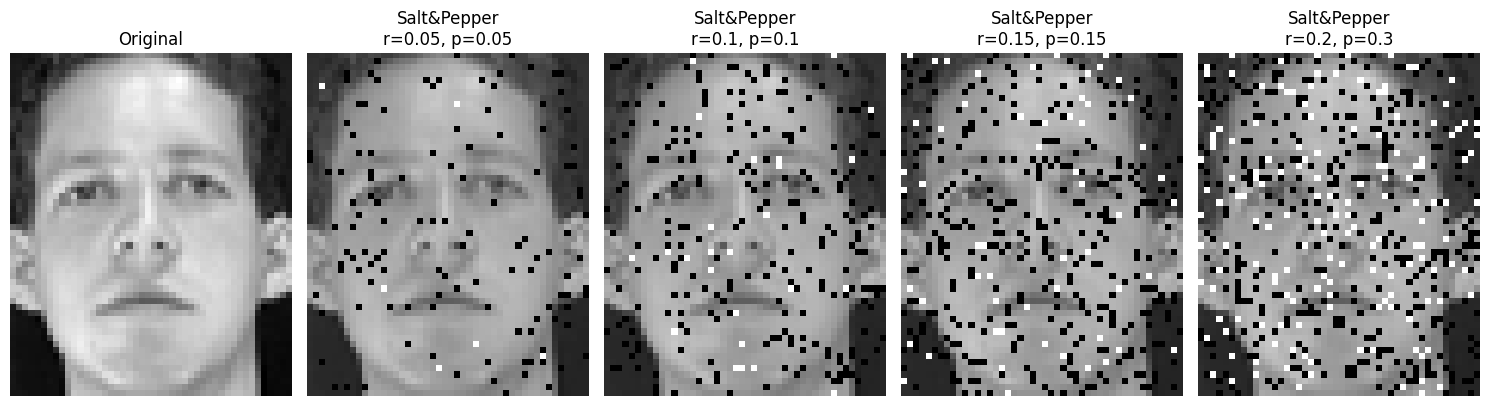

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Show the salt and pepper noise effect
index = 0
H, W = H0_ORL // reduce_ORL, W0_ORL // reduce_ORL
original_img = V_hat_ORL[:, index].reshape(H, W)

# Define different noise parameters
noise_levels = [
    (0.05, 0.05),
    (0.10, 0.10),
    (0.15, 0.15),
    (0.20, 0.30)
]

fig, axes = plt.subplots(1, len(noise_levels)+1, figsize=(15, 4))
axes[0].imshow(original_img, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')
for i, (r, p) in enumerate(noise_levels):
    noisy_img = add_salt_and_pepper_noise(original_img, r, p)
    axes[i+1].imshow(noisy_img, cmap='gray')
    axes[i+1].set_title(f"Salt&Pepper\nr={r}, p={p}")
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

In [9]:
# L2-Norm Based NMF

def L2_multiplicative_update_NMF(R, P, Q, steps=50):
    for step in range(steps):
        # To do here
        Pu = P*(R.dot(Q))/(P.dot(Q.T).dot(Q)+1e-7)
        Qu = Q*(R.T.dot(Pu))/(Q.dot(Pu.T).dot(Pu)+1e-7)
        
        e_P = np.sqrt(np.sum((Pu-P)**2, axis=(0,1)))/P.size
        e_Q = np.sqrt(np.sum((Qu-Q)**2, axis=(0,1)))/Q.size
        
        P = Pu
        Q = Qu
        

    return P, Q



In [10]:
# L1-Norm Based NMF

def l1_nmf(R, P, Q, steps=1000, lr=1e-4):

    for step in range(steps):
        R_hat = P @ Q.T
        diff = R_hat - R  # residuals
        sign = np.sign(diff) 
        # Gradients for L1 loss
        grad_P = sign @ Q    
        grad_Q = sign.T @ P  
        # Gradient descent update
        P = P - lr * grad_P
        Q = Q - lr * grad_Q
        P[P < 0] = 0
        Q[Q < 0] = 0

    return P, Q




In [11]:
# HypersurfaceNMF (robust, weighted multiplicative updates)
class HypersurfaceNMF:
    def __init__(self, rank, loss="charbonnier", eps=1e-3, sigma=1.0, delta=1.0,
                 max_outer=20, inner_iters=10, tol=1e-4, random_state=42):
        self.rank = rank
        self.loss = loss
        self.eps = eps
        self.sigma = sigma
        self.delta = delta
        self.max_outer = max_outer
        self.inner_iters = inner_iters
        self.tol = tol
        self.random_state = random_state
        self.W_ = None
        self.H_ = None

    def _weights_from_residual(self, E):
        if self.loss == "charbonnier":
            return 1.0 / (2.0 * np.sqrt(E*E + self.eps*self.eps) + 1e-12)

    def fit(self, V, V_ref=None):
        rng = np.random.default_rng(self.random_state)
        d, n = V.shape
        W = rng.random((d, self.rank)) + 1e-8
        H = rng.random((self.rank, n)) + 1e-8
        prev_rre = None
        for it in range(self.max_outer):
            E = V - W @ H
            Wgt = self._weights_from_residual(E)
            for _ in range(self.inner_iters):
                WH = W @ H
                W *= ((V * Wgt) @ H.T) / (((WH) * Wgt) @ H.T + 1e-12)
                W = np.maximum(W, 1e-12)
                WH = W @ H
                H *= (W.T @ (V * Wgt)) / (W.T @ ((WH) * Wgt) + 1e-12)
                H = np.maximum(H, 1e-12)
            if V_ref is not None:
                rre = np.linalg.norm(V_ref - W @ H) / (np.linalg.norm(V_ref) + 1e-12)
                if (prev_rre is not None) and (abs(prev_rre - rre) < self.tol):
                    break
                prev_rre = rre
        self.W_, self.H_ = W, H
        return self



In [12]:
# L2,1-Norm Based NMF
def l21_nmf(R, P, Q, steps=200, epsilon=1e-8):
    for step in range(steps):
        R_hat = P @ Q.T
        diff = R_hat - R  # residuals

        D = np.diag(1 / (2 * np.linalg.norm(diff, axis=0) + epsilon))
        P = P * ((R @ D @ Q) / (P @ Q.T @ D @ Q + epsilon))
        Q = Q * ((D @ R.T @ P) / (D @ Q @ P.T @ P + epsilon))
        
    return P, Q


### 2.2 Evaluate Clustering Performance

1. Accuracy.
    
    $$ Acc(Y, Y_{pred}) = \frac{1}{n}\sum\limits_{i=1}^n 1\{Y_{pred}(i) == Y(i)\}$$
        
2. Normalized Mutual Information (NMI).

    $$ NMI(Y, Y_{pred}) = \frac{2 * I(Y, Y_{pred})}{H(Y) + H(Y_{pred})} $$
    
   where $ I(\cdot,\cdot) $ is mutual information and $ H(\cdot) $ is entropy.

In [13]:
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from sklearn.metrics import normalized_mutual_info_score

def assign_cluster_label(X, Y):
    kmeans = KMeans(n_clusters=len(set(Y))).fit(X)
    Y_pred = np.zeros(Y.shape)
    for i in set(kmeans.labels_):
        ind = kmeans.labels_ == i
        Y_pred[ind] = Counter(Y[ind]).most_common(1)[0][0] # assign label.
    return Y_pred


==> Sweep r with fixed p = 0.2 | Dataset: ORL
-- r=0.00
-- r=0.05
-- r=0.10
-- r=0.15
-- r=0.20
-- r=0.25


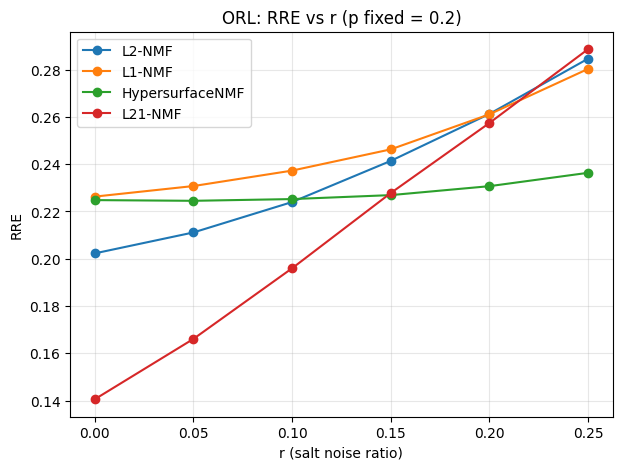

==> Sweep r with fixed p = 0.2 | Dataset: YaleB
-- r=0.00
-- r=0.05
-- r=0.10
-- r=0.15
-- r=0.20
-- r=0.25


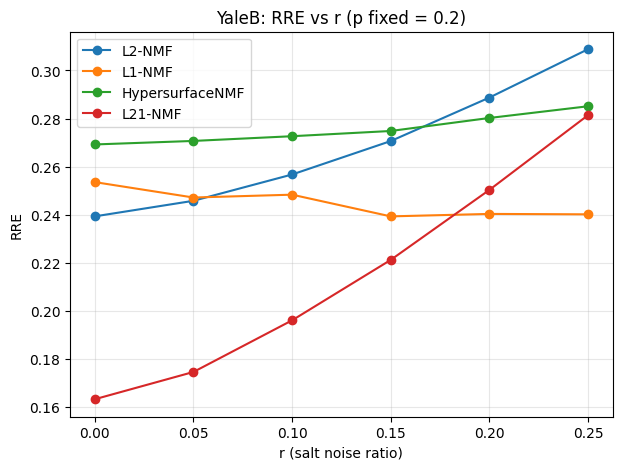

In [14]:
# RRE vs r with fixed p for YaleB and ORL
import numpy as np
import matplotlib.pyplot as plt

# Configuration
p_fixed = 0.2
r_values = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25]
steps_L2 = 50
steps_L1 = 1000
steps_L21 = 200
max_outer_hs = 20
inner_iters_hs = 10
K_ORL = 60
K_YaleB = 100

# ==== ORL ====
K = K_ORL
H_reduced_orl = H0_ORL // reduce_ORL
W_reduced_orl = W0_ORL // reduce_ORL

rre_l2_orl, rre_l1_orl, rre_l21_orl, rre_hs_orl = [], [], [], []

print('==> Sweep r with fixed p =', p_fixed, '| Dataset: ORL')
for r in r_values:
    print(f'-- r={r:.2f}')
    V_noisy = add_noise_to_dataset(V_hat_ORL, r=r, p=p_fixed, H=H_reduced_orl, W=W_reduced_orl)

    num_features, num_samples = V_noisy.shape
    rng = np.random.RandomState(42)
    P0 = rng.rand(num_features, K)
    Q0 = rng.rand(num_samples, K)

    P, Q = L2_multiplicative_update_NMF(V_noisy, P0.copy(), Q0.copy(), steps=steps_L2)
    rre_l2_orl.append(np.linalg.norm(V_hat_ORL - P @ Q.T) / np.linalg.norm(V_hat_ORL))

    P, Q = l1_nmf(V_noisy, P0.copy(), Q0.copy(), steps=steps_L1, lr=1e-4)
    rre_l1_orl.append(np.linalg.norm(V_hat_ORL - P @ Q.T) / np.linalg.norm(V_hat_ORL))

    model = HypersurfaceNMF(rank=K, loss="charbonnier", max_outer=max_outer_hs, inner_iters=inner_iters_hs, tol=1e-4, random_state=42)
    model.fit(V_noisy, V_ref=V_hat_ORL)
    W_hs, H_hs = model.W_, model.H_
    rre_hs_orl.append(np.linalg.norm(V_hat_ORL - W_hs @ H_hs) / np.linalg.norm(V_hat_ORL))

    P, Q = l21_nmf(V_noisy, P0.copy(), Q0.copy(), steps=steps_L21)
    rre_l21_orl.append(np.linalg.norm(V_hat_ORL - P @ Q.T) / np.linalg.norm(V_hat_ORL))

plt.figure(figsize=(7, 5))
plt.plot(r_values, rre_l2_orl, marker='o', label='L2-NMF')
plt.plot(r_values, rre_l1_orl, marker='o', label='L1-NMF')
plt.plot(r_values, rre_hs_orl, marker='o', label='HypersurfaceNMF')
plt.plot(r_values, rre_l21_orl, marker='o', label='L21-NMF')
plt.xlabel('r (salt noise ratio)')
plt.ylabel('RRE')
plt.title(f'ORL: RRE vs r (p fixed = {p_fixed})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ==== YaleB ====
K = K_YaleB
H_reduced = H0_YaleB // reduce_YaleB
W_reduced = W0_YaleB // reduce_YaleB

rre_l2, rre_l1, rre_l21, rre_hs = [], [], [], []

print('==> Sweep r with fixed p =', p_fixed, '| Dataset: YaleB')
for r in r_values:
    print(f'-- r={r:.2f}')
    V_noisy = add_noise_to_dataset(V_hat_YaleB, r=r, p=p_fixed, H=H_reduced, W=W_reduced)

    num_features, num_samples = V_noisy.shape
    rng = np.random.RandomState(42)
    P0 = rng.rand(num_features, K)
    Q0 = rng.rand(num_samples, K)

    P, Q = L2_multiplicative_update_NMF(V_noisy, P0.copy(), Q0.copy(), steps=steps_L2)
    rre_l2.append(np.linalg.norm(V_hat_YaleB - P @ Q.T) / np.linalg.norm(V_hat_YaleB))

    P, Q = l1_nmf(V_noisy, P0.copy(), Q0.copy(), steps=steps_L1, lr=1e-4)
    rre_l1.append(np.linalg.norm(V_hat_YaleB - P @ Q.T) / np.linalg.norm(V_hat_YaleB))

    model = HypersurfaceNMF(rank=K, loss="charbonnier", max_outer=max_outer_hs, inner_iters=inner_iters_hs, tol=1e-4, random_state=42)
    model.fit(V_noisy, V_ref=V_hat_YaleB)
    W_hs, H_hs = model.W_, model.H_
    rre_hs.append(np.linalg.norm(V_hat_YaleB - W_hs @ H_hs) / np.linalg.norm(V_hat_YaleB))

    P, Q = l21_nmf(V_noisy, P0.copy(), Q0.copy(), steps=steps_L21)
    rre_l21.append(np.linalg.norm(V_hat_YaleB - P @ Q.T) / np.linalg.norm(V_hat_YaleB))

plt.figure(figsize=(7, 5))
plt.plot(r_values, rre_l2, marker='o', label='L2-NMF')
plt.plot(r_values, rre_l1, marker='o', label='L1-NMF')
plt.plot(r_values, rre_hs, marker='o', label='HypersurfaceNMF')
plt.plot(r_values, rre_l21, marker='o', label='L21-NMF')
plt.xlabel('r (salt noise ratio)')
plt.ylabel('RRE')
plt.title(f'YaleB: RRE vs r (p fixed = {p_fixed})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


==> Sweep p with fixed r = 0.2 | Dataset: ORL
-- p=0.10
-- p=0.15
-- p=0.20
-- p=0.25
-- p=0.30


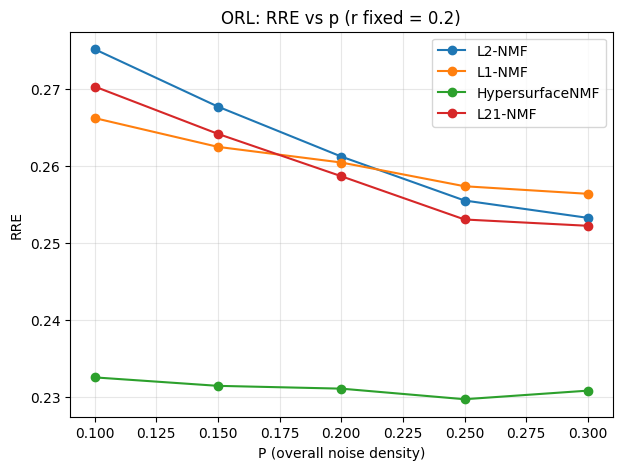

==> Sweep p with fixed r = 0.2 | Dataset: YaleB
-- p=0.10
-- p=0.15
-- p=0.20
-- p=0.25
-- p=0.30


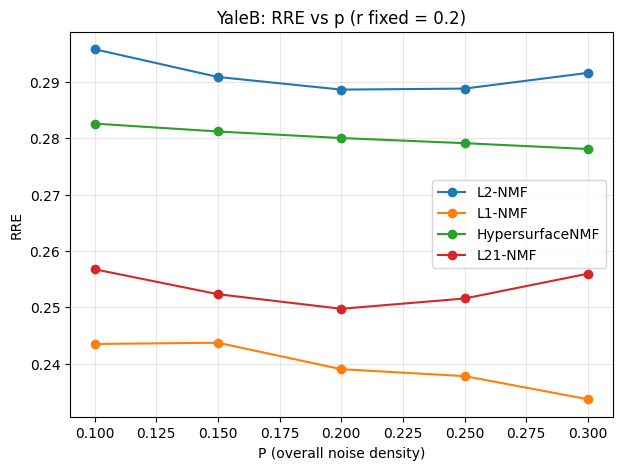

In [15]:
# RRE vs p with fixed r for YaleB and ORL
import numpy as np
import matplotlib.pyplot as plt

# Configuration
r_fixed= 0.2
p_values = [0.10, 0.15, 0.20, 0.25, 0.30]
steps_L2 = 50
steps_L1 = 1000
steps_L21 = 200
max_outer_hs = 20
inner_iters_hs = 10

# ==== ORL ====
K = K_ORL
H_reduced_orl = H0_ORL // reduce_ORL
W_reduced_orl = W0_ORL // reduce_ORL

rre_l2_orl, rre_l1_orl, rre_l21_orl, rre_hs_orl = [], [], [], []

print('==> Sweep p with fixed r =', r_fixed, '| Dataset: ORL')
for p in p_values:
    print(f'-- p={p:.2f}')
    V_noisy = add_noise_to_dataset(V_hat_ORL, r=r_fixed, p=p, H=H_reduced_orl, W=W_reduced_orl)

    num_features, num_samples = V_noisy.shape
    rng = np.random.RandomState(42)
    P0 = rng.rand(num_features, K)
    Q0 = rng.rand(num_samples, K)


    P, Q = L2_multiplicative_update_NMF(V_noisy, P0.copy(), Q0.copy(), steps=steps_L2)
    rre_l2_orl.append(np.linalg.norm(V_hat_ORL - P @ Q.T) / np.linalg.norm(V_hat_ORL))

    P, Q = l1_nmf(V_noisy, P0.copy(), Q0.copy(), steps=steps_L1, lr=1e-4)
    rre_l1_orl.append(np.linalg.norm(V_hat_ORL - P @ Q.T) / np.linalg.norm(V_hat_ORL))

    model = HypersurfaceNMF(rank=K, loss="charbonnier", max_outer=max_outer_hs, inner_iters=inner_iters_hs, tol=1e-4, random_state=42)
    model.fit(V_noisy, V_ref=V_hat_ORL)
    W_hs, H_hs = model.W_, model.H_
    rre_hs_orl.append(np.linalg.norm(V_hat_ORL - W_hs @ H_hs) / np.linalg.norm(V_hat_ORL))

    P, Q = l21_nmf(V_noisy, P0.copy(), Q0.copy(), steps=steps_L21)
    rre_l21_orl.append(np.linalg.norm(V_hat_ORL - P @ Q.T) / np.linalg.norm(V_hat_ORL))

plt.figure(figsize=(7, 5))
plt.plot(p_values, rre_l2_orl, marker='o', label='L2-NMF')
plt.plot(p_values, rre_l1_orl, marker='o', label='L1-NMF')
plt.plot(p_values, rre_hs_orl, marker='o', label='HypersurfaceNMF')
plt.plot(p_values, rre_l21_orl, marker='o', label='L21-NMF')
plt.xlabel('P (overall noise density)')
plt.ylabel('RRE')
plt.title(f'ORL: RRE vs p (r fixed = {r_fixed})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ==== YaleB ====
K = K_YaleB
H_reduced = H0_YaleB // reduce_YaleB
W_reduced = W0_YaleB // reduce_YaleB

rre_l2, rre_l1, rre_l21, rre_hs = [], [], [], []

print('==> Sweep p with fixed r =', r_fixed, '| Dataset: YaleB')
for p in p_values:
    print(f'-- p={p:.2f}')
    V_noisy = add_noise_to_dataset(V_hat_YaleB, r=r_fixed, p=p, H=H_reduced, W=W_reduced)

    num_features, num_samples = V_noisy.shape
    rng = np.random.RandomState(42)
    P0 = rng.rand(num_features, K)
    Q0 = rng.rand(num_samples, K)

    P, Q = L2_multiplicative_update_NMF(V_noisy, P0.copy(), Q0.copy(), steps=steps_L2)
    rre_l2.append(np.linalg.norm(V_hat_YaleB - P @ Q.T) / np.linalg.norm(V_hat_YaleB))

    P, Q = l1_nmf(V_noisy, P0.copy(), Q0.copy(), steps=steps_L1, lr=1e-4)
    rre_l1.append(np.linalg.norm(V_hat_YaleB - P @ Q.T) / np.linalg.norm(V_hat_YaleB))

    model = HypersurfaceNMF(rank=K, loss="charbonnier", max_outer=max_outer_hs, inner_iters=inner_iters_hs, tol=1e-4, random_state=42)
    model.fit(V_noisy, V_ref=V_hat_YaleB)
    W_hs, H_hs = model.W_, model.H_
    rre_hs.append(np.linalg.norm(V_hat_YaleB - W_hs @ H_hs) / np.linalg.norm(V_hat_YaleB))

    P, Q = l21_nmf(V_noisy, P0.copy(), Q0.copy(), steps=steps_L21)
    rre_l21.append(np.linalg.norm(V_hat_YaleB - P @ Q.T) / np.linalg.norm(V_hat_YaleB))

plt.figure(figsize=(7, 5))
plt.plot(p_values, rre_l2, marker='o', label='L2-NMF')
plt.plot(p_values, rre_l1, marker='o', label='L1-NMF')
plt.plot(p_values, rre_hs, marker='o', label='HypersurfaceNMF')
plt.plot(p_values, rre_l21, marker='o', label='L21-NMF')
plt.xlabel('P (overall noise density)')
plt.ylabel('RRE')
plt.title(f'YaleB: RRE vs p (r fixed = {r_fixed})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


==> Sweep k with fixed r = 0.2 | p = 0.2 | Dataset: ORL
-- k=20
-- k=40
-- k=60
-- k=80
-- k=100


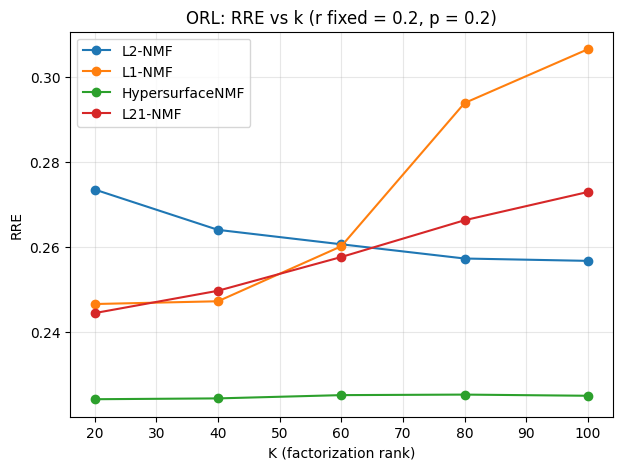

==> Sweep p with fixed r = 0.2 | p = 0.2 | Dataset: YaleB
-- k=100
-- k=150
-- k=200
-- k=250
-- k=300
-- k=500


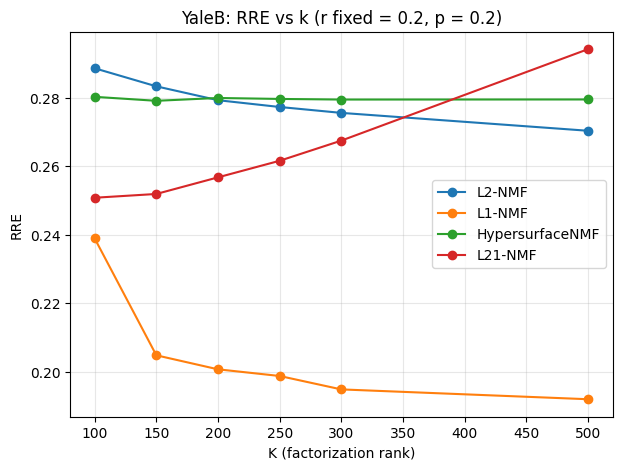

In [16]:
# RRE vs k with fixed r and p for YaleB and ORL
import numpy as np
import matplotlib.pyplot as plt

# Configuration
r_fixed= 0.2
p_fixed = 0.2
steps_L2 = 50
steps_L1 = 1000
steps_L21 = 200
max_outer_hs = 20
inner_iters_hs = 10

# ==== ORL ====
K_ORL_net = [20, 40, 60, 80, 100]
H_reduced_orl = H0_ORL // reduce_ORL
W_reduced_orl = W0_ORL // reduce_ORL

rre_l2_orl, rre_l1_orl, rre_l21_orl, rre_hs_orl = [], [], [], []

print('==> Sweep k with fixed r =', r_fixed, '| p =', p_fixed, '| Dataset: ORL')
for k in K_ORL_net:
    print(f'-- k={k}')
    V_noisy = add_noise_to_dataset(V_hat_ORL, r=r_fixed, p=p_fixed, H=H_reduced_orl, W=W_reduced_orl)

    num_features, num_samples = V_noisy.shape
    rng = np.random.RandomState(42)
    P0 = rng.rand(num_features, k)
    Q0 = rng.rand(num_samples, k)


    P, Q = L2_multiplicative_update_NMF(V_noisy, P0.copy(), Q0.copy(), steps=steps_L2)
    rre_l2_orl.append(np.linalg.norm(V_hat_ORL - P @ Q.T) / np.linalg.norm(V_hat_ORL))

    P, Q = l1_nmf(V_noisy, P0.copy(), Q0.copy(), steps=steps_L1, lr=1e-4)
    rre_l1_orl.append(np.linalg.norm(V_hat_ORL - P @ Q.T) / np.linalg.norm(V_hat_ORL))

    model = HypersurfaceNMF(rank=K, loss="charbonnier", max_outer=max_outer_hs, inner_iters=inner_iters_hs, tol=1e-4, random_state=42)
    model.fit(V_noisy, V_ref=V_hat_ORL)
    W_hs, H_hs = model.W_, model.H_
    rre_hs_orl.append(np.linalg.norm(V_hat_ORL - W_hs @ H_hs) / np.linalg.norm(V_hat_ORL))

    P, Q = l21_nmf(V_noisy, P0.copy(), Q0.copy(), steps=steps_L21)
    rre_l21_orl.append(np.linalg.norm(V_hat_ORL - P @ Q.T) / np.linalg.norm(V_hat_ORL))

plt.figure(figsize=(7, 5))
plt.plot(K_ORL_net, rre_l2_orl, marker='o', label='L2-NMF')
plt.plot(K_ORL_net, rre_l1_orl, marker='o', label='L1-NMF')
plt.plot(K_ORL_net, rre_hs_orl, marker='o', label='HypersurfaceNMF')
plt.plot(K_ORL_net, rre_l21_orl, marker='o', label='L21-NMF')
plt.xlabel('K (factorization rank)')
plt.ylabel('RRE')
plt.title(f'ORL: RRE vs k (r fixed = {r_fixed}, p = {p_fixed})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ==== YaleB ====
K_YaleB_net = [100, 150, 200, 250, 300, 500]
H_reduced = H0_YaleB // reduce_YaleB
W_reduced = W0_YaleB // reduce_YaleB

rre_l2, rre_l1, rre_l21, rre_hs = [], [], [], []

print('==> Sweep p with fixed r =', r_fixed, '| p =', p_fixed, '| Dataset: YaleB')
for k in K_YaleB_net:
    print(f'-- k={k}')
    V_noisy = add_noise_to_dataset(V_hat_YaleB, r=r_fixed, p=p_fixed, H=H_reduced, W=W_reduced)

    num_features, num_samples = V_noisy.shape
    rng = np.random.RandomState(42)
    P0 = rng.rand(num_features, k)
    Q0 = rng.rand(num_samples, k)

    P, Q = L2_multiplicative_update_NMF(V_noisy, P0.copy(), Q0.copy(), steps=steps_L2)
    rre_l2.append(np.linalg.norm(V_hat_YaleB - P @ Q.T) / np.linalg.norm(V_hat_YaleB))

    P, Q = l1_nmf(V_noisy, P0.copy(), Q0.copy(), steps=steps_L1, lr=1e-4)
    rre_l1.append(np.linalg.norm(V_hat_YaleB - P @ Q.T) / np.linalg.norm(V_hat_YaleB))

    model = HypersurfaceNMF(rank=K, loss="charbonnier", max_outer=max_outer_hs, inner_iters=inner_iters_hs, tol=1e-4, random_state=42)
    model.fit(V_noisy, V_ref=V_hat_YaleB)
    W_hs, H_hs = model.W_, model.H_
    rre_hs.append(np.linalg.norm(V_hat_YaleB - W_hs @ H_hs) / np.linalg.norm(V_hat_YaleB))

    P, Q = l21_nmf(V_noisy, P0.copy(), Q0.copy(), steps=steps_L21)
    rre_l21.append(np.linalg.norm(V_hat_YaleB - P @ Q.T) / np.linalg.norm(V_hat_YaleB))

plt.figure(figsize=(7, 5))
plt.plot(K_YaleB_net, rre_l2, marker='o', label='L2-NMF')
plt.plot(K_YaleB_net, rre_l1, marker='o', label='L1-NMF')
plt.plot(K_YaleB_net, rre_hs, marker='o', label='HypersurfaceNMF')
plt.plot(K_YaleB_net, rre_l21, marker='o', label='L21-NMF')
plt.xlabel('K (factorization rank)')
plt.ylabel('RRE')
plt.title(f'YaleB: RRE vs k (r fixed = {r_fixed}, p = {p_fixed})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [17]:
# Modified Acc, NMI, RRE evaluation: Random sampling 90% of dataset, calculate average and standard deviation over 5 trials, and plot boxplots

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, normalized_mutual_info_score
from collections import Counter
import pandas as pd

def evaluate_with_random_sampling(V_noisy, V_clean, Y_true, nmf_func, nmf_params, n_trials=5, sample_ratio=0.9):
    accuracies = []
    nmis = []
    rres = []
    
    n_samples = V_noisy.shape[1]
    n_selected = int(n_samples * sample_ratio)
    
    for trial in range(n_trials):
        print(f"Trial {trial + 1}/{n_trials}")
        
        # Randomly select 90% of the data
        np.random.seed(trial) 
        selected_indices = np.random.choice(n_samples, n_selected, replace=False)
        V_noisy_subset = V_noisy[:, selected_indices]
        V_clean_subset = V_clean[:, selected_indices]
        Y_subset = Y_true[selected_indices]
        
        # Run NMF algorithm
        if nmf_func == L2_multiplicative_update_NMF:
            # Re-initialize P and Q matrices for sampled data
            n_features, n_samples_subset = V_noisy_subset.shape
            rank = nmf_params.get('rank', nmf_params['P0'].shape[1])
            # Re-initialize P and Q matrices to match sampled data dimensions
            rng = np.random.RandomState(42 + trial)
            P_init = rng.rand(n_features, rank)
            Q_init = rng.rand(n_samples_subset, rank)
            
            P, Q = nmf_func(V_noisy_subset, P_init, Q_init, nmf_params['steps'])
            
        elif nmf_func == l1_nmf:
            n_features, n_samples_subset = V_noisy_subset.shape
            rank = nmf_params.get('rank', nmf_params['P0'].shape[1])
            rng = np.random.RandomState(42 + trial)
            P_init = rng.rand(n_features, rank)
            Q_init = rng.rand(n_samples_subset, rank)
            
            P, Q = nmf_func(V_noisy_subset, P_init, Q_init, nmf_params['steps'], nmf_params['lr'])
            
        elif nmf_func == l21_nmf:
            n_features, n_samples_subset = V_noisy_subset.shape
            rank = nmf_params.get('rank', nmf_params['P0'].shape[1])
            rng = np.random.RandomState(42 + trial)
            P_init = rng.rand(n_features, rank)
            Q_init = rng.rand(n_samples_subset, rank)
            
            P, Q = nmf_func(V_noisy_subset, P_init, Q_init, nmf_params['steps'])
            
        elif nmf_func == 'HypersurfaceNMF':
            # HypersurfaceNMF
            model = HypersurfaceNMF(rank=nmf_params['rank'], loss="charbonnier", 
                                  max_outer=nmf_params['max_outer'], 
                                  inner_iters=nmf_params['inner_iters'], 
                                  tol=1e-4, random_state=42 + trial)
            model.fit(V_noisy_subset, V_ref=V_clean_subset)
            P, Q = model.W_, model.H_.T
        
        # RRE
        rre = np.linalg.norm(V_clean_subset - P @ Q.T) / np.linalg.norm(V_clean_subset)
        rres.append(rre)
        
        # clustering performance
        Y_pred = assign_cluster_label(Q, Y_subset)
        
        # Accuracy
        acc = accuracy_score(Y_subset, Y_pred)
        accuracies.append(acc)
        
        # NMI
        nmi = normalized_mutual_info_score(Y_subset, Y_pred)
        nmis.append(nmi)
    
    return accuracies, nmis, rres

def plot_boxplots(results_dict, dataset_name):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    metrics = ['Accuracy', 'NMI', 'RRE']
    colors = ['skyblue', 'lightgreen', 'lightcoral']
    
    for i, metric in enumerate(metrics):
        data = []
        labels = []
        
        for method, values in results_dict.items():
            data.append(values[metric])
            labels.append(method)
        
        bp = axes[i].boxplot(data, tick_labels=labels, patch_artist=True)
        
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
        
        axes[i].set_title(f'{dataset_name} - {metric}')
        axes[i].set_ylabel(metric)
        axes[i].grid(True, alpha=0.3)
        axes[i].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()


Starting ORL dataset evaluation...
Evaluating L2-NMF...
Trial 1/5
Trial 2/5
Trial 3/5
Trial 4/5
Trial 5/5
Evaluating L1-NMF...
Trial 1/5
Trial 2/5
Trial 3/5
Trial 4/5
Trial 5/5
Evaluating HypersurfaceNMF...
Trial 1/5
Trial 2/5
Trial 3/5
Trial 4/5
Trial 5/5
Evaluating L21-NMF...
Trial 1/5
Trial 2/5
Trial 3/5
Trial 4/5
Trial 5/5

ORL dataset results statistics (mean±std over 5 trials):
L2-NMF         : Acc = 0.4083±0.0234, NMI = 0.6117±0.0160, RRE = 0.2613±0.0010
L1-NMF         : Acc = 0.5933±0.0196, NMI = 0.7709±0.0104, RRE = 0.2687±0.0022
HypersurfaceNMF: Acc = 0.4800±0.0133, NMI = 0.6707±0.0064, RRE = 0.2311±0.0013
L21-NMF        : Acc = 0.4928±0.0277, NMI = 0.6706±0.0223, RRE = 0.2621±0.0004


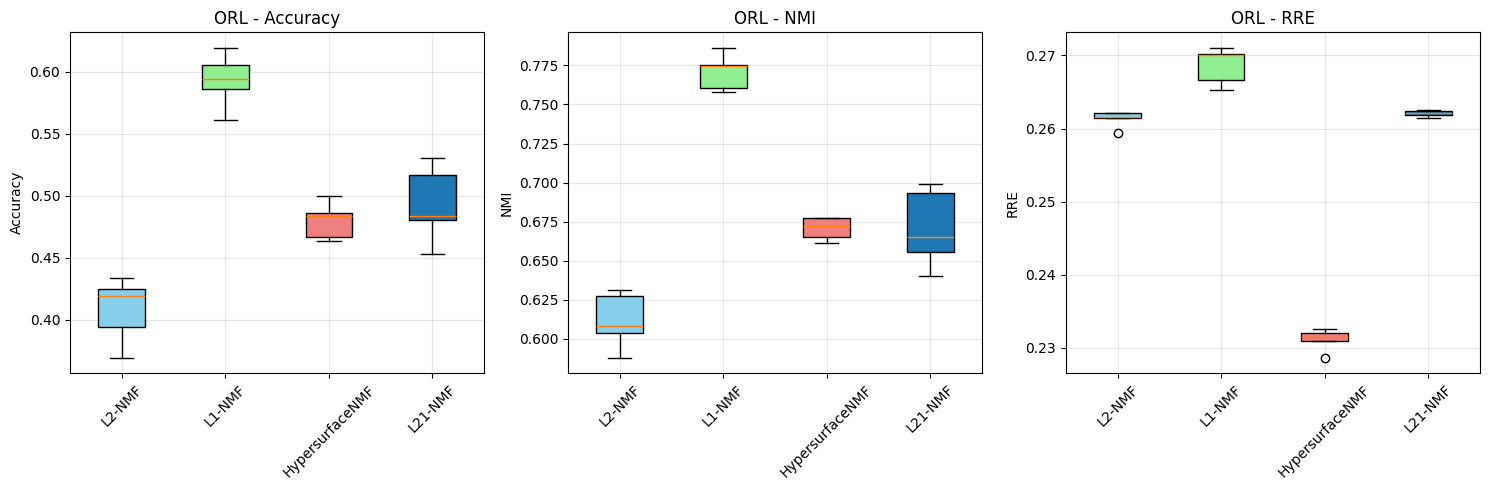

In [18]:
# Prepare parameters
n_trials = 5
sample_ratio = 0.9
K_ORL = 60
K_YaleB = 100

print("Starting ORL dataset evaluation...")

# ORL dataset evaluation
orl_results = {}

# L2-NMF
print("Evaluating L2-NMF...")
rng = np.random.RandomState(42)
P0_orl = rng.rand(V_ORL.shape[0], K_ORL)
Q0_orl = rng.rand(V_ORL.shape[1], K_ORL)
l2_params = {'P0': P0_orl, 'Q0': Q0_orl, 'steps': 50, 'rank': K_ORL}
acc_l2, nmi_l2, rre_l2 = evaluate_with_random_sampling(V_ORL, V_hat_ORL, Y_hat_ORL, 
                                                       L2_multiplicative_update_NMF, l2_params, n_trials, sample_ratio)
orl_results['L2-NMF'] = {'Accuracy': acc_l2, 'NMI': nmi_l2, 'RRE': rre_l2}

# L1-NMF
print("Evaluating L1-NMF...")
l1_params = {'P0': P0_orl, 'Q0': Q0_orl, 'steps': 1000, 'lr': 1e-4, 'rank': K_ORL}
acc_l1, nmi_l1, rre_l1 = evaluate_with_random_sampling(V_ORL, V_hat_ORL, Y_hat_ORL, 
                                                       l1_nmf, l1_params, n_trials, sample_ratio)
orl_results['L1-NMF'] = {'Accuracy': acc_l1, 'NMI': nmi_l1, 'RRE': rre_l1}

# HypersurfaceNMF
print("Evaluating HypersurfaceNMF...")
hs_params = {'rank': K_ORL, 'max_outer': 20, 'inner_iters': 10}
acc_hs, nmi_hs, rre_hs = evaluate_with_random_sampling(V_ORL, V_hat_ORL, Y_hat_ORL, 
                                                       'HypersurfaceNMF', hs_params, n_trials, sample_ratio)
orl_results['HypersurfaceNMF'] = {'Accuracy': acc_hs, 'NMI': nmi_hs, 'RRE': rre_hs}

# L21-NMF
print("Evaluating L21-NMF...")
l21_params = {'P0': P0_orl, 'Q0': Q0_orl, 'steps': 200, 'rank': K_ORL}
acc_l21, nmi_l21, rre_l21 = evaluate_with_random_sampling(V_ORL, V_hat_ORL, Y_hat_ORL, 
                                                          l21_nmf, l21_params, n_trials, sample_ratio)
orl_results['L21-NMF'] = {'Accuracy': acc_l21, 'NMI': nmi_l21, 'RRE': rre_l21}

# Calculate statistics and print results
print("\nORL dataset results statistics (mean±std over 5 trials):")
print("=" * 60)
for method, results in orl_results.items():
    acc_mean = np.mean(results['Accuracy'])
    acc_std = np.std(results['Accuracy'])
    nmi_mean = np.mean(results['NMI'])
    nmi_std = np.std(results['NMI'])
    rre_mean = np.mean(results['RRE'])
    rre_std = np.std(results['RRE'])
    
    print(f"{method:15s}: Acc = {acc_mean:.4f}±{acc_std:.4f}, NMI = {nmi_mean:.4f}±{nmi_std:.4f}, RRE = {rre_mean:.4f}±{rre_std:.4f}")

# ORL Box plot
plot_boxplots(orl_results, 'ORL')



YaleB
L2-NMF
Trial 1/5
Trial 2/5
Trial 3/5
Trial 4/5
Trial 5/5
L1-NMF
Trial 1/5
Trial 2/5
Trial 3/5
Trial 4/5
Trial 5/5
HypersurfaceNMF
Trial 1/5
Trial 2/5
Trial 3/5
Trial 4/5
Trial 5/5
L21-NMF
Trial 1/5
Trial 2/5
Trial 3/5
Trial 4/5
Trial 5/5

YaleB dataset results statistics (mean±std over 5 trials)::
L2-NMF         : Acc = 0.1159±0.0057, NMI = 0.1390±0.0068, RRE = 0.2877±0.0004
L1-NMF         : Acc = 0.2344±0.0035, NMI = 0.2858±0.0164, RRE = 0.2356±0.0007
HypersurfaceNMF: Acc = 0.0953±0.0029, NMI = 0.0976±0.0078, RRE = 0.2768±0.0011
L21-NMF        : Acc = 0.2236±0.0090, NMI = 0.3030±0.0178, RRE = 0.2520±0.0004


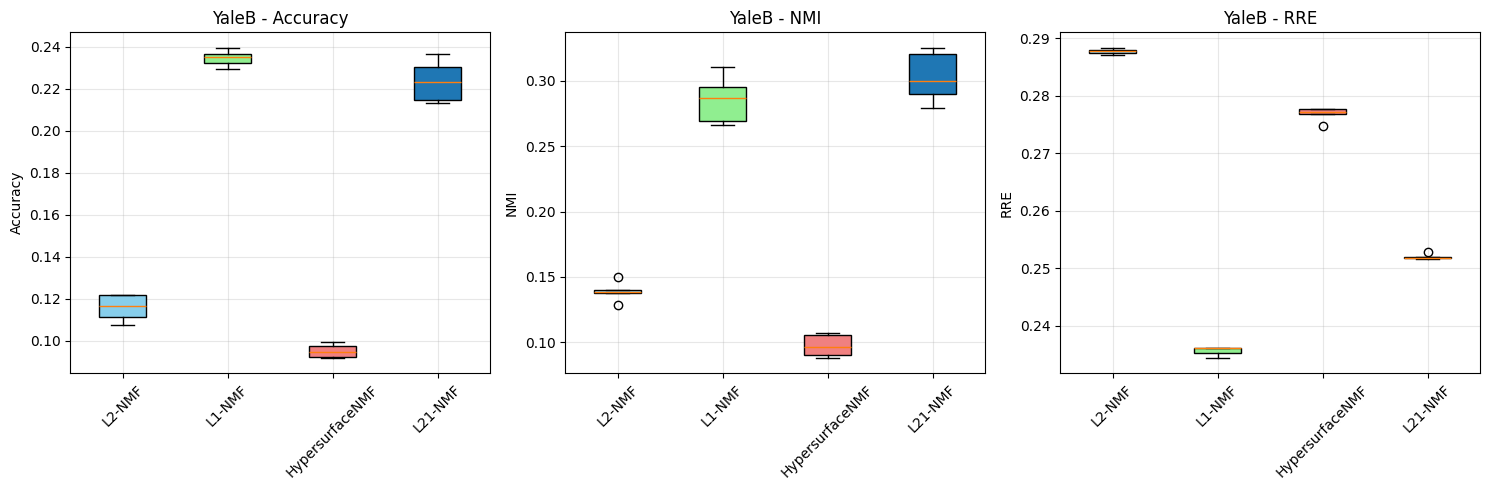

In [19]:
# YaleB
print("\nYaleB")

yaleb_results = {}

# L2-NMF
print("L2-NMF")
rng = np.random.RandomState(42)
P0_yaleb = rng.rand(V_YaleB.shape[0], K_YaleB)
Q0_yaleb = rng.rand(V_YaleB.shape[1], K_YaleB)
l2_params_yaleb = {'P0': P0_yaleb, 'Q0': Q0_yaleb, 'steps': 50, 'rank': K_YaleB}
acc_l2_yaleb, nmi_l2_yaleb, rre_l2_yaleb = evaluate_with_random_sampling(V_YaleB, V_hat_YaleB, Y_hat_YaleB, 
                                                                         L2_multiplicative_update_NMF, l2_params_yaleb, n_trials, sample_ratio)
yaleb_results['L2-NMF'] = {'Accuracy': acc_l2_yaleb, 'NMI': nmi_l2_yaleb, 'RRE': rre_l2_yaleb}

# L1-NMF
print("L1-NMF")
l1_params_yaleb = {'P0': P0_yaleb, 'Q0': Q0_yaleb, 'steps': 1000, 'lr': 1e-4, 'rank': K_YaleB}
acc_l1_yaleb, nmi_l1_yaleb, rre_l1_yaleb = evaluate_with_random_sampling(V_YaleB, V_hat_YaleB, Y_hat_YaleB, 
                                                                         l1_nmf, l1_params_yaleb, n_trials, sample_ratio)
yaleb_results['L1-NMF'] = {'Accuracy': acc_l1_yaleb, 'NMI': nmi_l1_yaleb, 'RRE': rre_l1_yaleb}

# HypersurfaceNMF
print("HypersurfaceNMF")
hs_params_yaleb = {'rank': K_YaleB, 'max_outer': 20, 'inner_iters': 10}
acc_hs_yaleb, nmi_hs_yaleb, rre_hs_yaleb = evaluate_with_random_sampling(V_YaleB, V_hat_YaleB, Y_hat_YaleB, 
                                                                          'HypersurfaceNMF', hs_params_yaleb, n_trials, sample_ratio)
yaleb_results['HypersurfaceNMF'] = {'Accuracy': acc_hs_yaleb, 'NMI': nmi_hs_yaleb, 'RRE': rre_hs_yaleb}

# L21-NMF
print("L21-NMF")
l21_params_yaleb = {'P0': P0_yaleb, 'Q0': Q0_yaleb, 'steps': 200, 'rank': K_YaleB}
acc_l21_yaleb, nmi_l21_yaleb, rre_l21_yaleb = evaluate_with_random_sampling(V_YaleB, V_hat_YaleB, Y_hat_YaleB, 
                                                                            l21_nmf, l21_params_yaleb, n_trials, sample_ratio)
yaleb_results['L21-NMF'] = {'Accuracy': acc_l21_yaleb, 'NMI': nmi_l21_yaleb, 'RRE': rre_l21_yaleb}

# Calculate statistics and print results
print("\nYaleB dataset results statistics (mean±std over 5 trials)::")
print("=" * 60)
for method, results in yaleb_results.items():
    acc_mean = np.mean(results['Accuracy'])
    acc_std = np.std(results['Accuracy'])
    nmi_mean = np.mean(results['NMI'])
    nmi_std = np.std(results['NMI'])
    rre_mean = np.mean(results['RRE'])
    rre_std = np.std(results['RRE'])
    
    print(f"{method:15s}: Acc = {acc_mean:.4f}±{acc_std:.4f}, NMI = {nmi_mean:.4f}±{nmi_std:.4f}, RRE = {rre_mean:.4f}±{rre_std:.4f}")

plot_boxplots(yaleb_results, 'YaleB')


In [20]:
def create_summary_table(results_dict, dataset_name):
    """The summary table of results"""
    summary_data = []
    for method, results in results_dict.items():
        acc_mean = np.mean(results['Accuracy'])
        acc_std = np.std(results['Accuracy'])
        nmi_mean = np.mean(results['NMI'])
        nmi_std = np.std(results['NMI'])
        rre_mean = np.mean(results['RRE'])
        rre_std = np.std(results['RRE'])
        
        summary_data.append({
            'Dataset': dataset_name,
            'Method': method,
            'Accuracy (Mean±Std)': f"{acc_mean:.4f}±{acc_std:.4f}",
            'NMI (Mean±Std)': f"{nmi_mean:.4f}±{nmi_std:.4f}",
            'RRE (Mean±Std)': f"{rre_mean:.4f}±{rre_std:.4f}"
        })
    
    return pd.DataFrame(summary_data)
orl_summary = create_summary_table(orl_results, 'ORL')
yaleb_summary = create_summary_table(yaleb_results, 'YaleB')
combined_summary = pd.concat([orl_summary, yaleb_summary], ignore_index=True)

print("result summary table:")
print(combined_summary.to_string(index=False))

# Just best metrics for each dataset
# ORL
orl_best_acc = max(orl_results.items(), key=lambda x: np.mean(x[1]['Accuracy']))
orl_best_nmi = max(orl_results.items(), key=lambda x: np.mean(x[1]['NMI']))
orl_best_rre = min(orl_results.items(), key=lambda x: np.mean(x[1]['RRE']))

print(f"ORL:")
print(f"  Best Accuracy: {orl_best_acc[0]} ({np.mean(orl_best_acc[1]['Accuracy']):.4f})")
print(f"  Best NMI: {orl_best_nmi[0]} ({np.mean(orl_best_nmi[1]['NMI']):.4f})")
print(f"  Best RRE: {orl_best_rre[0]} ({np.mean(orl_best_rre[1]['RRE']):.4f})")

# YaleB
yaleb_best_acc = max(yaleb_results.items(), key=lambda x: np.mean(x[1]['Accuracy']))
yaleb_best_nmi = max(yaleb_results.items(), key=lambda x: np.mean(x[1]['NMI']))
yaleb_best_rre = min(yaleb_results.items(), key=lambda x: np.mean(x[1]['RRE']))

print(f"\nYaleB:")
print(f"  Best Accuracy: {yaleb_best_acc[0]} ({np.mean(yaleb_best_acc[1]['Accuracy']):.4f})")
print(f"  Best NMI: {yaleb_best_nmi[0]} ({np.mean(yaleb_best_nmi[1]['NMI']):.4f})")
print(f"  Best RRE: {yaleb_best_rre[0]} ({np.mean(yaleb_best_rre[1]['RRE']):.4f})")


result summary table:
Dataset          Method Accuracy (Mean±Std) NMI (Mean±Std) RRE (Mean±Std)
    ORL          L2-NMF       0.4083±0.0234  0.6117±0.0160  0.2613±0.0010
    ORL          L1-NMF       0.5933±0.0196  0.7709±0.0104  0.2687±0.0022
    ORL HypersurfaceNMF       0.4800±0.0133  0.6707±0.0064  0.2311±0.0013
    ORL         L21-NMF       0.4928±0.0277  0.6706±0.0223  0.2621±0.0004
  YaleB          L2-NMF       0.1159±0.0057  0.1390±0.0068  0.2877±0.0004
  YaleB          L1-NMF       0.2344±0.0035  0.2858±0.0164  0.2356±0.0007
  YaleB HypersurfaceNMF       0.0953±0.0029  0.0976±0.0078  0.2768±0.0011
  YaleB         L21-NMF       0.2236±0.0090  0.3030±0.0178  0.2520±0.0004
ORL:
  Best Accuracy: L1-NMF (0.5933)
  Best NMI: L1-NMF (0.7709)
  Best RRE: HypersurfaceNMF (0.2311)

YaleB:
  Best Accuracy: L1-NMF (0.2344)
  Best NMI: L21-NMF (0.3030)
  Best RRE: L1-NMF (0.2356)
